# NASDAQ-100 (^NDX) — Análisis de retornos diarios

Histórico de 5 años. Foco: rendimiento % diario para entender el comportamiento típico de la base sobre la que se opera **MNQ**.

**Contenido:**
1. Carga de datos
2. Retornos diarios
3. Estadísticas globales
4. Estadísticas por día de la semana
5. Estadísticas por mes
6. Distribución (histograma + Q-Q)
7. Bandas ±1σ / ±2σ → rango esperado
8. Traducción a $ USD por contrato MNQ

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == 'analysis' else Path.cwd()
CACHE = ROOT / 'data' / 'cache' / 'ndx.parquet'

df = pd.read_parquet(CACHE)
print(f'Rango: {df.index.min().date()} → {df.index.max().date()}  |  {len(df)} días hábiles')
df.tail()

Rango: 2021-05-12 → 2026-05-08  |  1254 días hábiles


Price,Open,High,Low,Close,Volume
date,,,,,
2026-05-04,27731.339844,27822.369141,27504.089844,27651.820312,7849180000
2026-05-05,27895.050781,28065.630859,27844.230469,28015.060547,8090030000
2026-05-06,28234.019531,28608.679688,28208.230469,28599.169922,8864150000
2026-05-07,28612.539062,28825.519531,28440.050781,28563.949219,9118880000
2026-05-08,28768.119141,29234.990234,28751.210938,29234.990234,9577150000


## 2. Retornos diarios

`ret_pct` = retorno porcentual close-to-close. `ret_pts` = mismo movimiento expresado en puntos del NDX (útil para sizing en MNQ).

In [2]:
df['ret_pct'] = df['Close'].pct_change() * 100
df['ret_pts'] = df['Close'].diff()
df['dow'] = df.index.day_name()
df['month'] = df.index.month_name()

df[['Close', 'ret_pct', 'ret_pts', 'dow']].tail(10)

Price,Close,ret_pct,ret_pts,dow
date,,,,
2026-04-27,27305.679688,0.007361,2.009766,Monday
2026-04-28,27029.009766,-1.013232,-276.669922,Tuesday
2026-04-29,27186.980469,0.584449,157.970703,Wednesday
2026-04-30,27452.119141,0.975241,265.138672,Thursday
2026-05-01,27710.359375,0.940693,258.240234,Friday
2026-05-04,27651.820312,-0.211253,-58.539062,Monday
2026-05-05,28015.060547,1.313621,363.240234,Tuesday
2026-05-06,28599.169922,2.084983,584.109375,Wednesday
2026-05-07,28563.949219,-0.123153,-35.220703,Thursday


## 3. Estadísticas globales

Lo importante:
- **mean** ≈ retorno diario promedio (típicamente cercano a 0)
- **std** = volatilidad diaria → la métrica más útil para definir bandas
- **skew** = asimetría (negativo → cola izquierda más larga, las caídas son más bruscas que las subidas)
- **kurtosis** = qué tan "gordas" son las colas vs una normal (>0 = más eventos extremos de lo que la normal predice)

In [3]:
r = df['ret_pct'].dropna()
stats_global = pd.Series({
    'count': len(r),
    'mean': r.mean(),
    'median': r.median(),
    'std': r.std(),
    'min': r.min(),
    'max': r.max(),
    'skew': r.skew(),
    'kurtosis (exceso)': r.kurtosis(),
    'pct días positivos': (r > 0).mean() * 100,
})
stats_global.round(3)

count                 1253.000
mean                     0.075
median                   0.119
std                      1.425
min                     -6.067
max                     12.022
skew                     0.192
kurtosis (exceso)        5.265
pct días positivos      55.706
dtype: float64

## 4. Por día de la semana

¿Existe un patrón sistemático lunes-viernes? La media debería ser muy parecida; si algún día tiene σ notablemente mayor, ese día requiere stops más anchos.

In [4]:
order_dow = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
by_dow = df.groupby('dow')['ret_pct'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).reindex(order_dow)
by_dow['% días +'] = df.groupby('dow')['ret_pct'].apply(lambda s: (s > 0).mean() * 100).reindex(order_dow)
by_dow.round(3)

,count,mean,median,std,min,max,% días +
dow,,,,,,,
Monday,232,0.161,0.222,1.237,-4.602,4.021,62.500
Tuesday,259,0.028,0.048,1.272,-5.543,3.428,52.124
Wednesday,257,0.174,0.155,1.554,-5.060,12.022,59.302
Thursday,251,-0.028,0.002,1.559,-5.415,7.487,50.199
Friday,254,0.045,0.109,1.459,-6.067,3.699,54.724


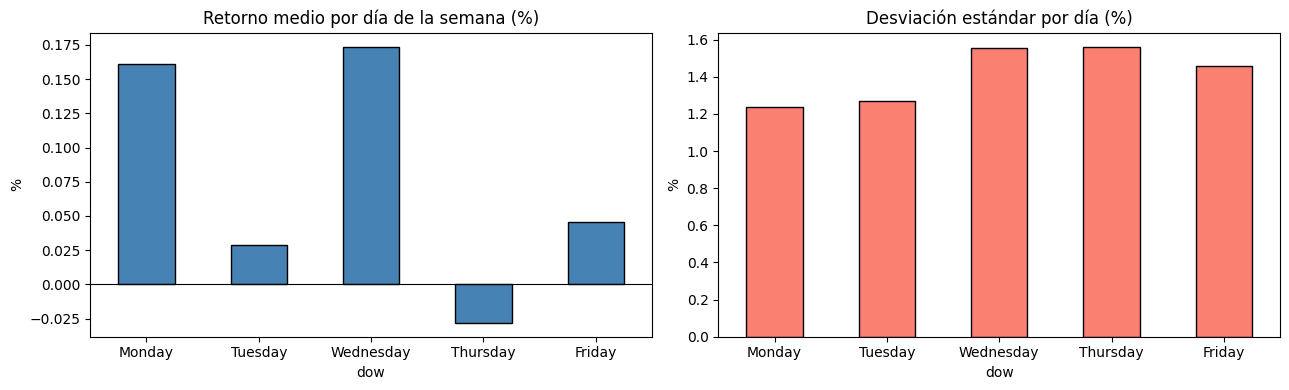

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
by_dow['mean'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Retorno medio por día de la semana (%)')
axes[0].set_ylabel('%')

by_dow['std'].plot(kind='bar', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Desviación estándar por día (%)')
axes[1].set_ylabel('%')

for ax in axes:
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 5. Por mes

Estacionalidad: ¿hay meses sistemáticamente más volátiles (ej. octubre) o más alcistas (ej. noviembre-diciembre, "Santa rally")?

In [6]:
order_month = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
by_month = df.groupby('month')['ret_pct'].agg(['count', 'mean', 'median', 'std']).reindex(order_month)
by_month.round(3)

,count,mean,median,std
month,,,,
January,101,0.072,0.136,1.345
February,96,-0.044,0.050,1.461
March,109,0.024,-0.043,1.543
April,103,-0.002,0.106,2.101
May,104,0.318,0.155,1.516
June,103,0.155,0.240,1.313
July,105,0.188,0.174,1.158
August,111,-0.001,0.025,1.252
September,103,-0.134,0.080,1.195


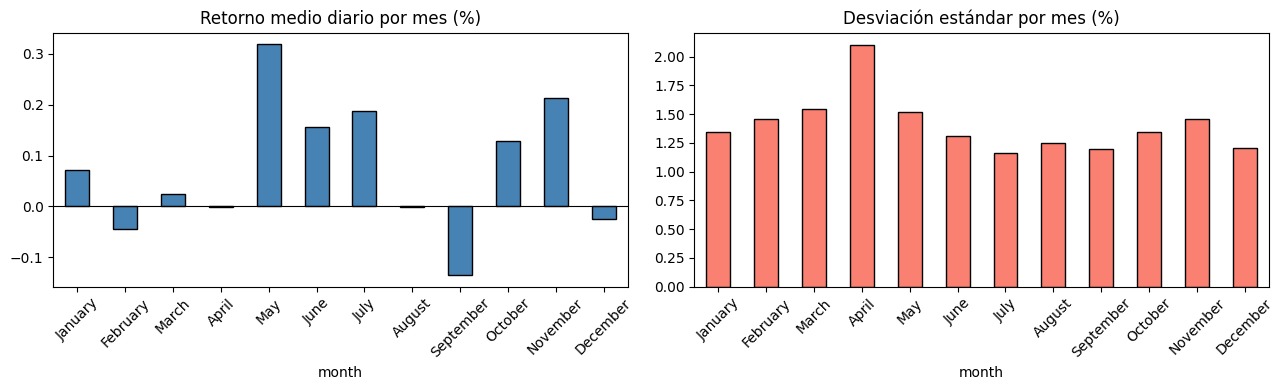

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
by_month['mean'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Retorno medio diario por mes (%)')
by_month['std'].plot(kind='bar', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Desviación estándar por mes (%)')
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 6. Distribución

**Histograma vs normal:** la curva roja es la normal teórica con la misma media y σ. Si las barras son más altas en el centro Y en los extremos que la curva, la distribución tiene **colas gordas** (eventos extremos más frecuentes que lo "normal").

**Q-Q plot:** si todos los puntos cayeran sobre la línea diagonal, los retornos serían perfectamente normales. Lo típico en mercados es que los extremos se desvíen hacia abajo a la izquierda y hacia arriba a la derecha → confirmando colas gordas.

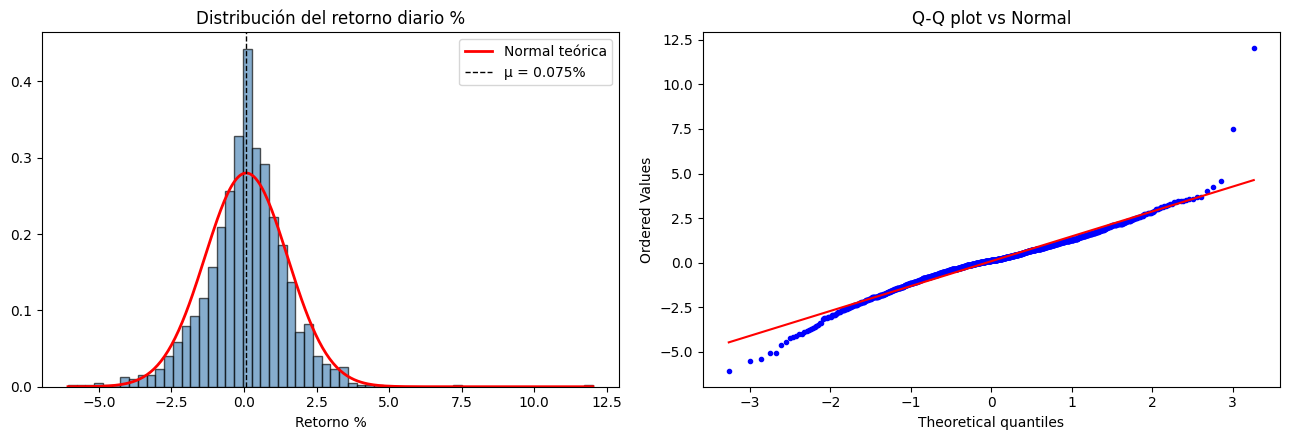

Jarque-Bera: stat=1440.6, p-value=0.00e+00
→ p < 0.05 rechaza normalidad (esperado en retornos de mercado).


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(r, bins=60, density=True, alpha=0.65, color='steelblue', edgecolor='black')
x = np.linspace(r.min(), r.max(), 300)
axes[0].plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'r-', lw=2, label='Normal teórica')
axes[0].axvline(r.mean(), color='black', linestyle='--', lw=1, label=f'μ = {r.mean():.3f}%')
axes[0].set_title('Distribución del retorno diario %')
axes[0].set_xlabel('Retorno %')
axes[0].legend()

stats.probplot(r, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot vs Normal')
axes[1].get_lines()[0].set_markersize(3)

plt.tight_layout()
plt.show()

jb_stat, jb_p = stats.jarque_bera(r)
print(f'Jarque-Bera: stat={jb_stat:.1f}, p-value={jb_p:.2e}')
print('→ p < 0.05 rechaza normalidad (esperado en retornos de mercado).')

## 7. Bandas ±1σ / ±2σ — rango esperado de movimiento diario

Bajo el supuesto (imperfecto) de normalidad:
- **±1σ** cubre ≈ 68% de los días
- **±2σ** cubre ≈ 95%
- **±3σ** cubre ≈ 99.7%

En mercados reales, por las colas gordas, los movimientos >2σ ocurren con MAYOR frecuencia que la teórica. Igual sirve como referencia rápida de "qué movimiento es normal vs anómalo".

In [9]:
mu, sigma = r.mean(), r.std()
bands = pd.DataFrame({
    'banda': ['μ - 2σ', 'μ - 1σ', 'μ', 'μ + 1σ', 'μ + 2σ'],
    'retorno %': [mu - 2*sigma, mu - sigma, mu, mu + sigma, mu + 2*sigma],
})
bands['retorno % esperado teórico'] = ['~2.5%', '~16%', '50%', '~84%', '~97.5%']
for col, lo, hi in [('±1σ', mu - sigma, mu + sigma), ('±2σ', mu - 2*sigma, mu + 2*sigma)]:
    cobertura = ((r >= lo) & (r <= hi)).mean() * 100
    print(f'Cobertura observada {col}: {cobertura:.1f}%')
bands.round(3)

Cobertura observada ±1σ: 74.1%
Cobertura observada ±2σ: 95.1%


,banda,retorno %,retorno % esperado teórico
0,μ - 2σ,-2.776,~2.5%
1,μ - 1σ,-1.350,~16%
2,μ,0.075,50%
3,μ + 1σ,1.500,~84%
4,μ + 2σ,2.925,~97.5%


## 8. Traducción a $ USD por contrato MNQ

**MNQ:** 1 punto NDX = $2 USD por contrato. Tick = 0.25 punto = $0.50.

Convertimos las bandas % al equivalente en puntos NDX y dólares por contrato MNQ, usando el último cierre como referencia.

In [10]:
MNQ_DOLLARS_PER_POINT = 2.0
last_close = df['Close'].iloc[-1]

table = pd.DataFrame({
    'banda': ['-2σ', '-1σ', 'media', '+1σ', '+2σ'],
    'retorno %': [mu - 2*sigma, mu - sigma, mu, mu + sigma, mu + 2*sigma],
})
table['movimiento (puntos NDX)'] = (table['retorno %'] / 100) * last_close
table['$ por contrato MNQ'] = table['movimiento (puntos NDX)'] * MNQ_DOLLARS_PER_POINT

print(f'Referencia: último close = {last_close:,.2f}')
print(f'σ diaria del NDX: {sigma:.3f}%  →  ≈ {sigma/100*last_close:.1f} puntos  →  ${sigma/100*last_close*MNQ_DOLLARS_PER_POINT:.2f} por MNQ\n')
table.round(2)

Referencia: último close = 29,234.99
σ diaria del NDX: 1.425%  →  ≈ 416.7 puntos  →  $833.35 por MNQ



,banda,retorno %,movimiento (puntos NDX),$ por contrato MNQ
0,-2σ,-2.78,-811.48,-1622.95
1,-1σ,-1.35,-394.80,-789.60
2,media,0.07,21.87,43.75
3,+1σ,1.50,438.55,877.10
4,+2σ,2.93,855.22,1710.45


### Interpretación práctica para MNQ

- **σ = movimiento típico de un día.** Stops más estrechos que ~1σ probablemente serán pateados por ruido.
- **Movimientos > 2σ** ocurren ~5% del tiempo según la normal, pero en realidad un poco más por colas gordas (revisar Jarque-Bera arriba).
- Esta es una visión estática de **media ± σ**; no captura **volatility clustering** (días volátiles vienen en racimo). Para eso haría falta GARCH o ATR. Lo dejamos como siguiente paso si te interesa.

### Próximos pasos posibles
1. **Volatilidad rolling** (σ móvil 20/60d) para ver cómo cambia el régimen.
2. **Gaps de apertura** (cierre vs apertura del día siguiente) — relevante para futuros que cotizan casi 24h.
3. **Análisis intradiario** con datos de 1m/5m del NQ para patrones de sesión RTH.
4. **Backtest** de una regla simple basada en σ (ej. fade de extensiones >2σ).